In [ ]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use. extract_notebook_figures.py will
# override these via a cell injected right below this one.
#
# Add notebook-level globals here, e.g.:
#     CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-xxxx"
#     CHECKPOINT_FILE = "step_0.pt"


# Look Within: a single Cayley step, illustrated

Hardcoded `f`, `U_0`, `U_1`, and `K_R` (rank 2). The domain is split into three equal $120^\circ$ wedges from the centre:

- **upper-left wedge** — `f` has a circle here, `U_0` is constant here.
- **upper-right wedge** — empty.
- **bottom wedge** — `U_1` is a triangle here.

We call `iso._joint_cayley_step` as a black box, integrate over $t \in [0, 1]$, and snapshot 8 frames. The expected story: as $t$ grows, the circle in the upper-left fades and a triangle materialises in the bottom — a function-space rotation in the rank-2 plane spanned by $U_0, U_1$.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from infidictionary.neural_isometries.eulerian import EulerianIsometry

torch.manual_seed(0)

## 1. Grid and three-wedge tessellation

In [2]:
N_per_side = 256
N = N_per_side ** 2

xs = torch.linspace(0.0, 1.0, N_per_side)
ys = torch.linspace(0.0, 1.0, N_per_side)
X, Y = torch.meshgrid(xs, ys, indexing='ij')
coords = torch.stack([X.flatten(), Y.flatten()], dim=-1)  # (N, 2)
logabsdet = torch.zeros(N)                                # uniform on [0,1]^2

# Polar angle from domain centre (0.5, 0.5), wrapped to [0, 2pi)
dx = coords[:, 0] - 0.5
dy = coords[:, 1] - 0.5
phi = torch.atan2(dy, dx)
phi = (phi + 2 * np.pi) % (2 * np.pi)

PI = float(np.pi)
# Splits at 90, 210, 330 degrees -> three equal 120-degree wedges
mask_upper_left  = (phi >= PI / 2)     & (phi < 7 * PI / 6)
mask_bottom      = (phi >= 7 * PI / 6) & (phi < 11 * PI / 6)
mask_upper_right = (phi >= 11 * PI / 6) | (phi < PI / 2)

## 2. Hardcode `f`, `U_0`, `U_1`

- `f`: circle inside the upper-left wedge.
- `U_0`: indicator of the upper-left wedge (constant inside, zero outside).
- `U_1`: triangle inside the bottom wedge.

In [3]:
# Circle inside upper-left wedge
circle_center = torch.tensor([
    0.5 + 0.27 * float(np.cos(np.deg2rad(150))),
    0.5 + 0.27 * float(np.sin(np.deg2rad(150))),
])
circle_radius = 0.10
dist_to_center = torch.sqrt(
    (coords[:, 0] - circle_center[0]) ** 2
    + (coords[:, 1] - circle_center[1]) ** 2
)
f_field = ((dist_to_center < circle_radius) & mask_upper_left).float()  # (N,)

# U_0: constant on upper-left wedge
U_0 = mask_upper_left.float()

# U_1: triangle (base on bottom, apex up) inside bottom wedge
v0 = torch.tensor([0.40, 0.18])
v1 = torch.tensor([0.60, 0.18])
v2 = torch.tensor([0.50, 0.36])

def in_triangle(pts, a, b, c):
    def sgn(p, p1, p2):
        return (p[..., 0] - p2[0]) * (p1[1] - p2[1]) - (p1[0] - p2[0]) * (p[..., 1] - p2[1])
    d1 = sgn(pts, a, b)
    d2 = sgn(pts, b, c)
    d3 = sgn(pts, c, a)
    has_neg = (d1 < 0) | (d2 < 0) | (d3 < 0)
    has_pos = (d1 > 0) | (d2 > 0) | (d3 > 0)
    return ~(has_neg & has_pos)

U_1 = (in_triangle(coords, v0, v1, v2) & mask_bottom).float()

# Pack to the shapes the Cayley step expects
U = torch.stack([U_0, U_1], dim=-1).unsqueeze(-1)   # (N, R=2, C=1)
f = f_field.unsqueeze(0).unsqueeze(-1)              # (B=1, N, C=1)

### Sanity-check the inputs

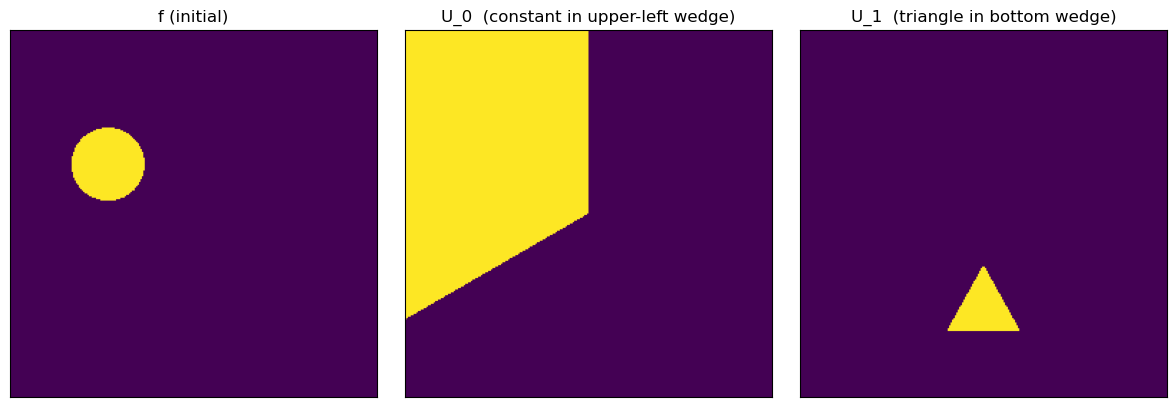

In [4]:
def imshow_field(ax, field_N, title, vmin=None, vmax=None):
    img = field_N.reshape(N_per_side, N_per_side).cpu().numpy()
    ax.imshow(img.T, origin='lower', cmap='viridis',
              extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
imshow_field(axes[0], f.squeeze(),  'f (initial)')
imshow_field(axes[1], U_0,          'U_0  (constant in upper-left wedge)')
imshow_field(axes[2], U_1,          'U_1  (triangle in bottom wedge)')
plt.tight_layout()
plt.show()

## 3. Run the Cayley step as a blackbox

All the knobs you can play with live in the next cell:

- `angle` — the off-diagonal entry of the skew-symmetrised generator $K_R - K_R^\top$.
- `acceleration` — the per-step `base_acceleration` parameter, which scales $\beta = \tfrac{1}{2}\Delta t \cdot a$.
- `n_steps` — how many small Euler steps to chain over $t \in [0,1]$ (kept divisible by 7 so 8 snapshots are evenly spaced).

In [5]:
# ---- Tunable knobs ----
angle        = 1.5    # off-diagonal of K_R - K_R^T
acceleration = 50.0    # passed straight to _joint_cayley_step
n_steps      = 56     # total Euler steps; 56 = 7 * 8 -> snapshots at multiples of 8
# -----------------------

# K_R chosen so that K_R - K_R^T = [[0, angle], [-angle, 0]]
K_R = torch.tensor([[0.0, angle], [0.0, 0.0]])

# Minimal isometry instance — we only call ._joint_cayley_step on it.
iso = EulerianIsometry(
    coords_dim=2,
    channels_dim=1,
    rank=2,
    base_acceleration=1.0,
    scalar_field_partial=None,
    atom_shuffling_K=2,
    n_time_freqs=4,
    kr_hidden_dims=(8,),
    atom_selector_hidden_dims=(8,),
)
iso.shuffle_model_state(n_steps)   # required before eval() — sets tspan internally
iso.eval()

tspan = torch.linspace(0.0, 1.0, n_steps + 1)
snap_steps = list(np.linspace(0, n_steps, 8).astype(int))  # [0, 8, 16, ..., 56]

snapshots = [(0.0, f.clone())]
current = f.clone()

with torch.no_grad():
    for i in range(n_steps):
        t0, t1 = float(tspan[i]), float(tspan[i + 1])
        current = iso._joint_cayley_step(
            t0, t1, U, K_R, None, logabsdet, current, acceleration
        )
        if (i + 1) in snap_steps:
            snapshots.append((t1, current.clone()))

len(snapshots)


8

## 4. Eight snapshots

Single shared symmetric colour scale so positive (yellow) and negative (purple) values are both legible — the rotation pushes mass into `U_1` with a sign, so the triangle materialises as a coherent dark blob while the upper-left wedge fades.

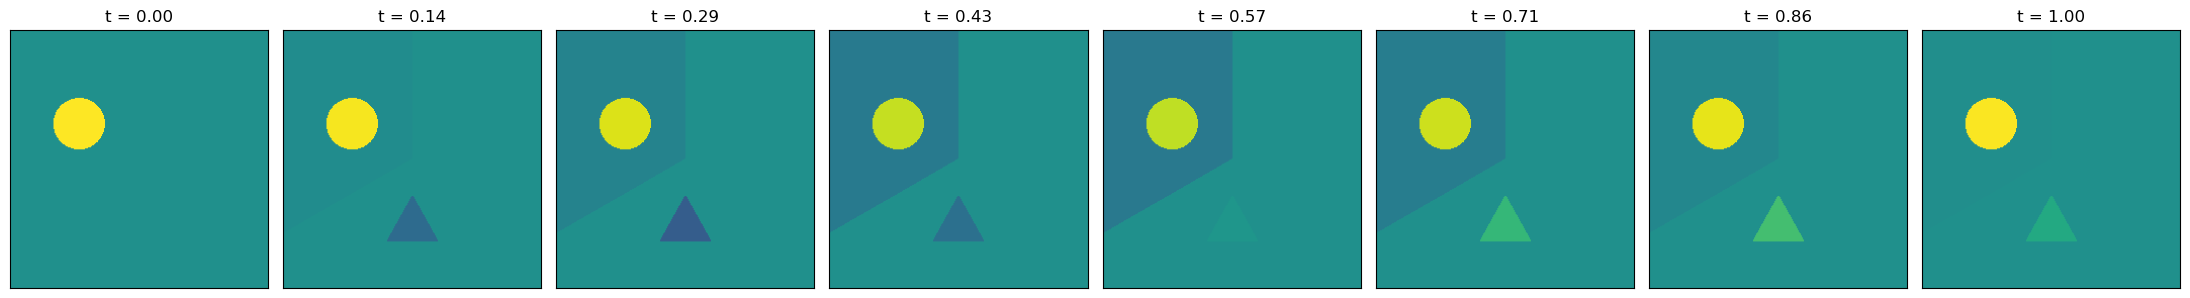

In [6]:
all_vals = torch.cat([s[1].flatten() for s in snapshots])
vmax = float(all_vals.abs().max())
vmin = -vmax

fig, axes = plt.subplots(1, 8, figsize=(22, 3.2))
for ax, (t, snap) in zip(axes, snapshots):
    imshow_field(ax, snap.squeeze(), f't = {t:.2f}', vmin=vmin, vmax=vmax)
plt.tight_layout()
plt.show()

## 5. Norm sanity check

The Cayley step is an isometry, so $\|f\|_{L^2}$ should be preserved across snapshots up to linear-solve precision.

In [7]:
for t, snap in snapshots:
    norm = snap.pow(2).mean().sqrt().item()
    print(f't = {t:.2f}   ||f||_L2 = {norm:.6f}')

t = 0.00   ||f||_L2 = 0.176690
t = 0.14   ||f||_L2 = 0.176690
t = 0.29   ||f||_L2 = 0.176690
t = 0.43   ||f||_L2 = 0.176690
t = 0.57   ||f||_L2 = 0.176690
t = 0.71   ||f||_L2 = 0.176690
t = 0.86   ||f||_L2 = 0.176690
t = 1.00   ||f||_L2 = 0.176690


## 6. A reusable runner

Pull the boilerplate into a helper so the next two examples stay tight.

In [8]:
def run_cayley_snapshots(f_init, U, K_R, n_steps, acceleration, logabsdet, n_snapshots=8):
    iso = EulerianIsometry(
        coords_dim=2, channels_dim=1, rank=2,
        base_acceleration=1.0,
        scalar_field_partial=None,
        atom_shuffling_K=2,
        n_time_freqs=4,
        kr_hidden_dims=(8,),
        atom_selector_hidden_dims=(8,),
    )
    iso.shuffle_model_state(n_steps)
    iso.eval()

    tspan = torch.linspace(0.0, 1.0, n_steps + 1)
    snap_set = set(np.linspace(0, n_steps, n_snapshots).astype(int).tolist())

    snapshots = [(0.0, f_init.clone())]
    current = f_init.clone()
    with torch.no_grad():
        for i in range(n_steps):
            t0, t1 = float(tspan[i]), float(tspan[i + 1])
            current = iso._joint_cayley_step(
                t0, t1, U, K_R, None, logabsdet, current, acceleration
            )
            if (i + 1) in snap_set:
                snapshots.append((t1, current.clone()))
    return snapshots


def plot_snapshots(snapshots, symmetric=True, figsize=(22, 3.2)):
    all_vals = torch.cat([s[1].flatten() for s in snapshots])
    if symmetric:
        vmax = float(all_vals.abs().max())
        vmin = -vmax
    else:
        vmax = float(all_vals.max())
        vmin = float(all_vals.min())
    fig, axes = plt.subplots(1, len(snapshots), figsize=figsize)
    for ax, (t, snap) in zip(axes, snapshots):
        imshow_field(ax, snap.squeeze(), f't = {t:.2f}', vmin=vmin, vmax=vmax)
    plt.tight_layout()
    plt.show()


## 7. Mirroring (a function-space rotation that is *not* a domain rotation)

Split the domain at $x = 0.5$. Place the cartoon on the **left**; that's both `f` and `U_0`. Place the **mirror image** of the cartoon on the **right**; that's `U_1`. The Cayley flow rotates `f` from the `U_0` direction to the `U_1` direction in $L^2(\Omega)$ — and what you *see* is the cartoon hopping across the symmetry axis, mirrored. There is no domain transformation happening here, only a function-space rotation.

We normalise `U_0`, `U_1` to unit norm so the rotation in the $(U_0, U_1)$ plane is a clean SO(2) rotation. Choosing $K_R = \begin{pmatrix}0 & 0\\ \theta & 0\end{pmatrix}$ makes the skew generator rotate $a_0 \mapsto +a_1$, and the total angle is $\mathrm{acceleration} \cdot \theta \approx \pi/2$.

Unnorm L2 norm: 0.5400
Overlap rho = 0.6702  (0 = orthogonal, 1 = identical)


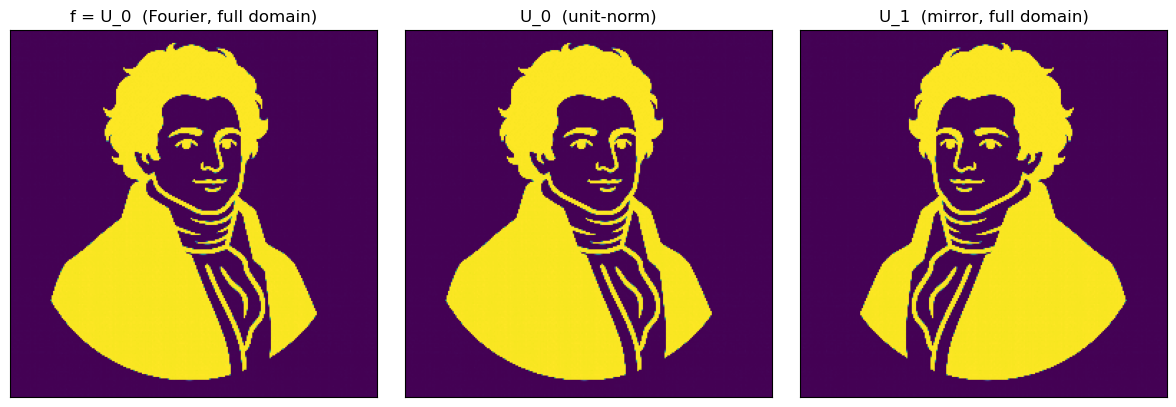

In [9]:
from PIL import Image

img_pil = Image.open('../assets/fourier_cartoon.png').convert('RGBA')
bg      = Image.new('RGBA', img_pil.size, (255, 255, 255, 255))
img_pil = Image.alpha_composite(bg, img_pil).convert('L')
img_np  = np.asarray(img_pil, dtype=np.float32) / 255.0
img_np  = 1.0 - img_np          # invert: drawing is the energy
img_t   = torch.from_numpy(img_np)

def image_on_region(coords, img, x_min, x_max, y_min, y_max, mirror_x=False):
    H, W = img.shape
    x, y = coords[:, 0], coords[:, 1]
    in_region = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
    u = (x_max - x) / (x_max - x_min) if mirror_x else (x - x_min) / (x_max - x_min)
    v = (y_max - y) / (y_max - y_min)
    px = (u * (W - 1)).clamp(0, W - 1).long()
    py = (v * (H - 1)).clamp(0, H - 1).long()
    return img[py, px] * in_region.float()

# Both U_0 and U_1 span the full domain.
f_full   = image_on_region(coords, img_t, 0.0, 1.0, 0.0, 1.0, mirror_x=False)
U_1_full = image_on_region(coords, img_t, 0.0, 1.0, 0.0, 1.0, mirror_x=True)

rho = float((f_full * U_1_full).mean() / f_full.pow(2).mean())
print(f'Unnorm L2 norm: {f_full.pow(2).mean().sqrt().item():.4f}')
print(f'Overlap rho = {rho:.4f}  (0 = orthogonal, 1 = identical)')

U_0_unit_m = f_full   / f_full.pow(2).mean().sqrt()
U_1_unit_m = U_1_full / U_1_full.pow(2).mean().sqrt()

U_mirror = torch.stack([U_0_unit_m, U_1_unit_m], dim=-1).unsqueeze(-1)
f_mirror = f_full.unsqueeze(0).unsqueeze(-1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
imshow_field(axes[0], f_mirror.squeeze(), 'f = U_0  (Fourier, full domain)')
imshow_field(axes[1], U_0_unit_m, 'U_0  (unit-norm)')
imshow_field(axes[2], U_1_unit_m, 'U_1  (mirror, full domain)')
plt.tight_layout()
plt.show()


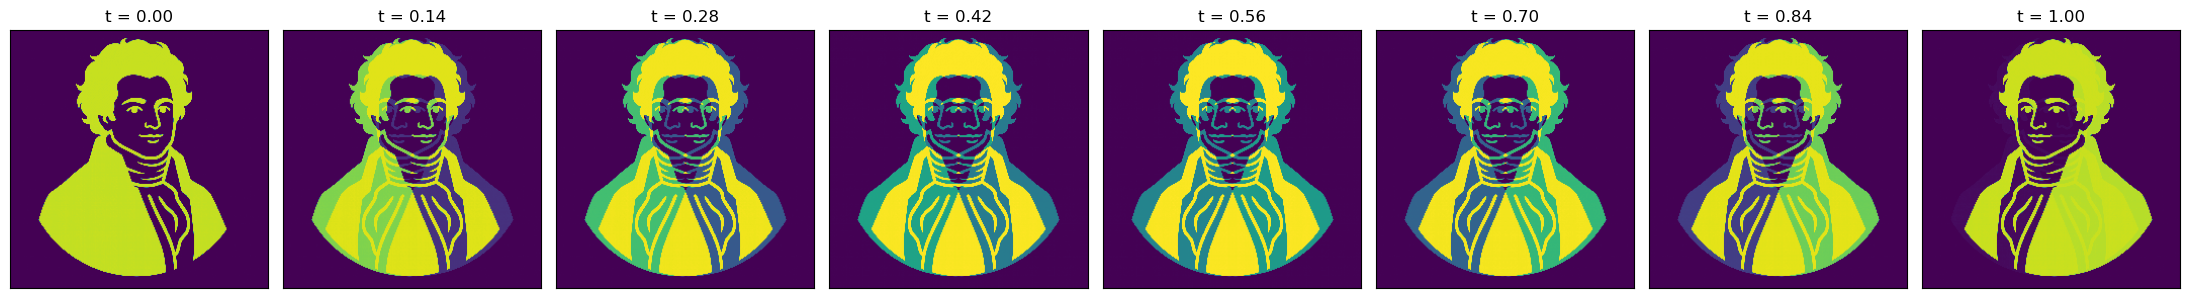

t = 0.00   ||f||_L2 = 0.540021
t = 0.14   ||f||_L2 = 0.540021
t = 0.28   ||f||_L2 = 0.540021
t = 0.42   ||f||_L2 = 0.540021
t = 0.56   ||f||_L2 = 0.540021
t = 0.70   ||f||_L2 = 0.540021
t = 0.84   ||f||_L2 = 0.540021
t = 1.00   ||f||_L2 = 0.540021


In [10]:
angle_mirror        = 1.0
acceleration_mirror = float(np.pi / 2) * 0.7
K_R_mirror = torch.tensor([[0.0, 0.0], [angle_mirror, 0.0]])

snaps_mirror = run_cayley_snapshots(
    f_mirror, U_mirror, K_R_mirror,
    n_steps=64, acceleration=acceleration_mirror,
    logabsdet=logabsdet, n_snapshots=8,
)
plot_snapshots(snaps_mirror, symmetric=False)

for t, snap in snaps_mirror:
    print(f't = {t:.2f}   ||f||_L2 = {snap.pow(2).mean().sqrt().item():.6f}')


### 7b. An arbitrary signal through the same Cayley

Feed a signal `g` unrelated to Fourier through the *exact same* `U_mirror` and `K_R_mirror`. The Cayley decomposes `g` as

$$g = \langle U_0,g\rangle U_0 + \langle U_1,g\rangle U_1 + g_\perp$$

and rotates only the in-plane component by $\pi/2$, leaving $g_\perp$ untouched. The Fourier / mirror-Fourier fingerprints of `g` get swapped; everything else is frozen.

<U_0, g> = 0.06407   <U_1, g> = 0.07881


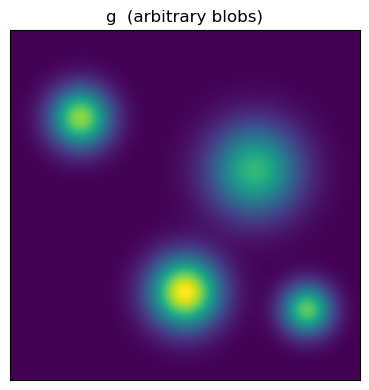

In [11]:
# Arbitrary signal: four Gaussian blobs with no portrait structure.
g_field = torch.zeros(N)
for gcx, gcy, gsig, amp in [
    (0.20, 0.75, 0.06, 1.0),
    (0.70, 0.60, 0.09, 0.8),
    (0.50, 0.25, 0.07, 1.2),
    (0.85, 0.20, 0.05, 0.9),
]:
    d2 = (coords[:, 0] - gcx) ** 2 + (coords[:, 1] - gcy) ** 2
    g_field = g_field + amp * torch.exp(-d2 / (2 * gsig ** 2))
g_field = g_field / g_field.max()
g_batch = g_field.unsqueeze(0).unsqueeze(-1)

a0 = float((g_field * U_0_unit_m).mean())
a1 = float((g_field * U_1_unit_m).mean())
print(f'<U_0, g> = {a0:.5f}   <U_1, g> = {a1:.5f}')

fig, ax = plt.subplots(figsize=(4, 4))
imshow_field(ax, g_field, 'g  (arbitrary blobs)')
plt.tight_layout(); plt.show()


Gaussian overlap with Fourier U_0: 0.11081  U_1: 0.05497
(small -> most of g is in g_perp; only a tiny Fourier component gets rotated)


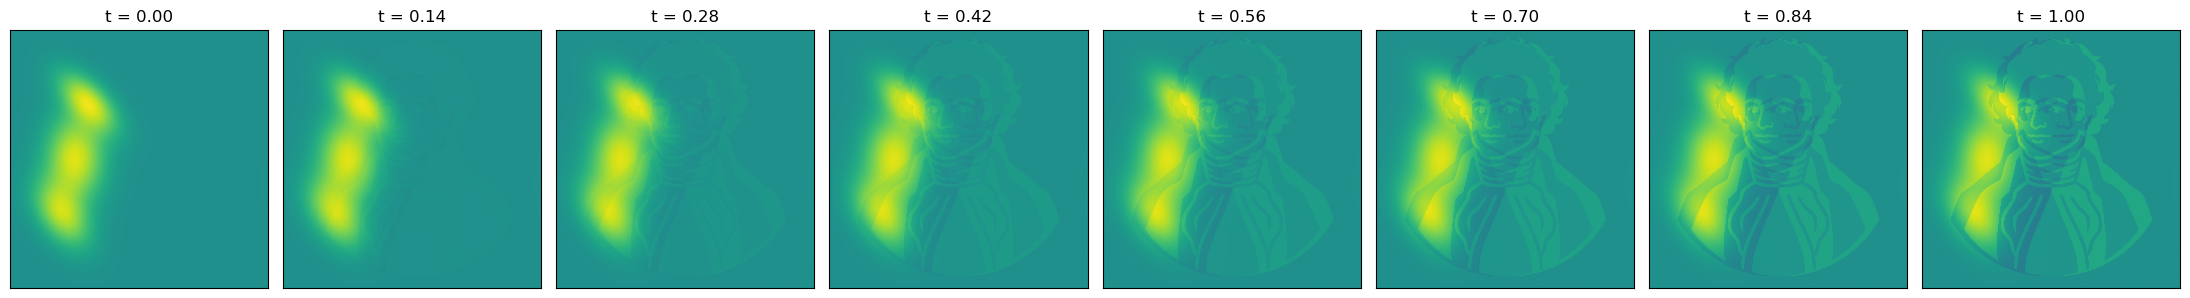

t = 0.00   ||g||_L2 = 0.266786
t = 0.14   ||g||_L2 = 0.266786
t = 0.28   ||g||_L2 = 0.266786
t = 0.42   ||g||_L2 = 0.266786
t = 0.56   ||g||_L2 = 0.266786
t = 0.70   ||g||_L2 = 0.266786
t = 0.84   ||g||_L2 = 0.266787
t = 1.00   ||g||_L2 = 0.266786


In [12]:
# Feed the Gaussian mixture through the *Fourier-portrait* Cayley (U_mirror) —
# this is the "failing" example: the Cayley only rotates the U_0/U_1 fingerprint
# of the input; everything orthogonal to the portrait basis stays frozen.
# The Gaussian blobs have a small overlap with the portrait basis, so what you
# see is a tiny Fourier ghost being injected while the blobs barely change.

# Recompute the Gaussian mixture inline (same specs as section 9).
def _gauss_mix(coords, specs, weights):
    import math
    result = torch.zeros(coords.shape[0], 1)
    for spec, w in zip(specs, weights):
        mu    = torch.tensor(spec['center'], dtype=coords.dtype)
        th    = spec['angle']
        sx, sy = spec['sigmas']
        c_, s_ = math.cos(th), math.sin(th)
        R = torch.tensor([[c_, -s_], [s_, c_]], dtype=coords.dtype)
        prec = R @ torch.diag(torch.tensor([1/sx**2, 1/sy**2])) @ R.T
        d = coords - mu
        d = d - torch.round(d)
        maha = (d @ prec * d).sum(-1, keepdim=True)
        result = result + w * torch.exp(-0.5 * maha)
    return result

_specs = [
    {'center': [0.25, 0.50], 'angle': 0.0,           'sigmas': (0.08, 0.12)},
    {'center': [0.20, 0.28], 'angle': __import__('math').pi / 5,   'sigmas': (0.06, 0.10)},
    {'center': [0.30, 0.72], 'angle': -__import__('math').pi / 4,  'sigmas': (0.10, 0.05)},
]
_weights = [1.0, 0.8, 0.9]

g_gauss = _gauss_mix(coords, _specs, _weights).squeeze(-1)  # (N,)
g_gauss_batch = g_gauss.unsqueeze(0).unsqueeze(-1)          # (1, N, 1)

a0 = float((g_gauss * U_0_unit_m).mean())
a1 = float((g_gauss * U_1_unit_m).mean())
print(f'Gaussian overlap with Fourier U_0: {a0:.5f}  U_1: {a1:.5f}')
print('(small -> most of g is in g_perp; only a tiny Fourier component gets rotated)')

snaps_g = run_cayley_snapshots(
    g_gauss_batch, U_mirror, K_R_mirror,
    n_steps=64, acceleration=acceleration_mirror,
    logabsdet=logabsdet, n_snapshots=8,
)
plot_snapshots(snaps_g, symmetric=True)

for t, snap in snaps_g:
    print(f't = {t:.2f}   ||g||_L2 = {snap.pow(2).mean().sqrt().item():.6f}')


## 8. Sad $\to$ happy

Same construction with hand-sketched faces. `f = U_0` is a sad face on the left half, `U_1` is a happy face on the right half. The Cayley flow in the $(U_0, U_1)$ plane fades the sad face out on the left and materialises the happy face on the right.

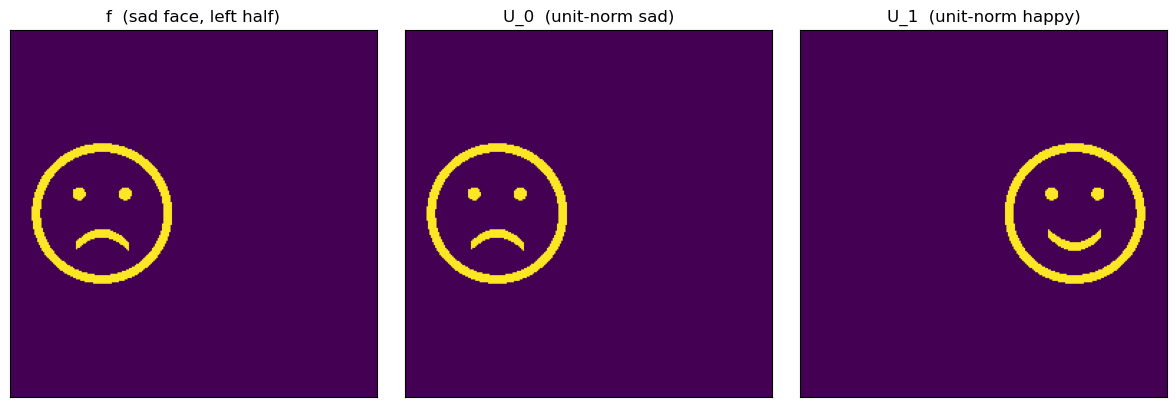

In [13]:
def make_face_field(coords, center, radius, sad=True):
    """Outline ring + two eye dots + parabolic mouth (sad: cap, happy: cup)."""
    x, y = coords[:, 0], coords[:, 1]
    cx, cy = center
    field = torch.zeros_like(x)

    # outline ring
    thick_face = 0.012
    dist = torch.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    field = field + ((dist >= radius - thick_face) & (dist <= radius + thick_face)).float()

    # eyes
    eye_dx = 0.35 * radius
    eye_dy = 0.30 * radius
    eye_r  = 0.10 * radius
    for sign in (-1.0, 1.0):
        d = torch.sqrt((x - (cx + sign * eye_dx)) ** 2 + (y - (cy + eye_dy)) ** 2)
        field = field + (d < eye_r).float()

    # mouth: parabolic arc; sad -> apex up, happy -> apex down
    mouth_y_low  = cy - 0.50 * radius
    mouth_y_high = cy - 0.30 * radius
    mouth_half_w = 0.40 * radius
    mouth_thick  = 0.012
    in_x = torch.abs(x - cx) <= mouth_half_w
    s    = (x - cx) / mouth_half_w
    if sad:
        y_arc = mouth_y_low + (mouth_y_high - mouth_y_low) * (1 - s ** 2)
    else:
        y_arc = mouth_y_low + (mouth_y_high - mouth_y_low) * (s ** 2)
    near = torch.abs(y - y_arc) <= mouth_thick
    field = field + (in_x & near).float()

    return field.clamp(0.0, 1.0)


sad_face   = make_face_field(coords, center=(0.25, 0.5), radius=0.18, sad=True)
happy_face = make_face_field(coords, center=(0.75, 0.5), radius=0.18, sad=False)

U_0_face_unit = sad_face   / sad_face.pow(2).mean().sqrt()
U_1_face_unit = happy_face / happy_face.pow(2).mean().sqrt()

U_face = torch.stack([U_0_face_unit, U_1_face_unit], dim=-1).unsqueeze(-1)
f_face = sad_face.unsqueeze(0).unsqueeze(-1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
imshow_field(axes[0], f_face.squeeze(), 'f  (sad face, left half)')
imshow_field(axes[1], U_0_face_unit, 'U_0  (unit-norm sad)')
imshow_field(axes[2], U_1_face_unit, 'U_1  (unit-norm happy)')
plt.tight_layout()
plt.show()


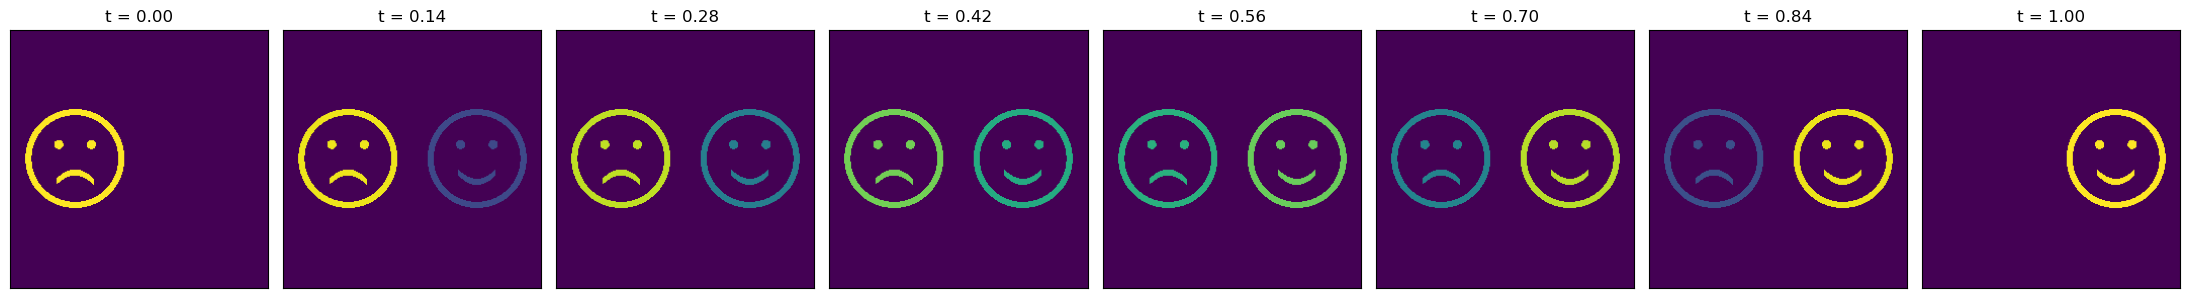

t = 0.00   ||f||_L2 = 0.179984
t = 0.14   ||f||_L2 = 0.179984
t = 0.28   ||f||_L2 = 0.179984
t = 0.42   ||f||_L2 = 0.179984
t = 0.56   ||f||_L2 = 0.179984
t = 0.70   ||f||_L2 = 0.179984
t = 0.84   ||f||_L2 = 0.179984
t = 1.00   ||f||_L2 = 0.179984


In [14]:
angle_face        = 1.0
acceleration_face = float(np.pi / 2)
K_R_face = torch.tensor([[0.0, 0.0], [angle_face, 0.0]])

snaps_face = run_cayley_snapshots(
    f_face, U_face, K_R_face,
    n_steps=64, acceleration=acceleration_face,
    logabsdet=logabsdet, n_snapshots=8,
)
plot_snapshots(snaps_face, symmetric=False)

for t, snap in snaps_face:
    print(f't = {t:.2f}   ||f||_L2 = {snap.pow(2).mean().sqrt().item():.6f}')
